# Predictive Maintenance — AI4I 2020 Dataset

This notebook builds a complete **machine failure prediction** system using the AI4I 2020 dataset.
The goal is to predict whether a machine will fail based on its sensor readings,
enabling maintenance teams to act before a breakdown occurs.

---

## Notebook Structure

| Phase | Description |
|-------|-------------|
| 1 | Setup & Imports |
| 2 | Load & Inspect Dataset |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Feature Analysis & Reduction |
| 5 | Data Preprocessing |
| 6 | Model Training & Learning Curves |
| 7 | Final Evaluation on Unseen Test Data |

---

> **Dataset:** AI4I 2020 Predictive Maintenance Dataset — 10,000 samples, 6 sensor features, binary failure label.  
> **Problem type:** Binary classification (Failure = 1, No Failure = 0)  
> **Key challenge:** Severe class imbalance (~3% failures only)

---
## Phase 1 — Setup & Imports

All libraries are imported here once, at the top, so the rest of the notebook stays clean.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Machine Learning ──────────────────────────────────────────
from sklearn.model_selection  import train_test_split, learning_curve
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.decomposition    import PCA
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm              import SVC
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.metrics          import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score,
    accuracy_score, matthews_corrcoef,
    classification_report
)

# ── Class imbalance handler ───────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plot style ────────────────────────────────────────────────
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.3
sns.set_palette('husl')

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


---
## Phase 2 — Load & Inspect Dataset

We load the CSV and do a quick inspection to understand:
- How many rows and columns we have
- What data types each column has
- Whether any values are missing

**Key columns:**

| Column | Description |
|--------|-------------|
| `Type` | Machine quality grade: L (Low), M (Medium), H (High) |
| `Air temperature [K]` | Ambient air temperature |
| `Process temperature [K]` | Machine operating temperature |
| `Rotational speed [rpm]` | Spindle speed |
| `Torque [Nm]` | Force applied to the spindle |
| `Tool wear [min]` | Cumulative tool usage time |
| `Machine failure` | **Target** — 1 = failure, 0 = no failure |


In [2]:
# Load dataset — place 'ai4i2020.csv' in the same folder as this notebook
df = pd.read_csv("../ai4i2020.csv")

print(f"Dataset shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values : {df.isnull().sum().sum()}")
df.head(10)

Dataset shape  : 10,000 rows × 14 columns
Missing values : 0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [3]:
# Column types and unique value counts
print("=== Column Overview ===")
for col in df.columns:
    print(f"  {col:38s} | {str(df[col].dtype):10s} | {df[col].nunique()} unique values")

print("\n=== Statistical Summary ===")
df.describe().round(3)

=== Column Overview ===
  UDI                                    | int64      | 10000 unique values
  Product ID                             | str        | 10000 unique values
  Type                                   | str        | 3 unique values
  Air temperature [K]                    | float64    | 93 unique values
  Process temperature [K]                | float64    | 82 unique values
  Rotational speed [rpm]                 | int64      | 941 unique values
  Torque [Nm]                            | float64    | 577 unique values
  Tool wear [min]                        | int64      | 246 unique values
  Machine failure                        | int64      | 2 unique values
  TWF                                    | int64      | 2 unique values
  HDF                                    | int64      | 2 unique values
  PWF                                    | int64      | 2 unique values
  OSF                                    | int64      | 2 unique values
  RNF                   

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5000.500,300.005,310.006,1538.776,39.987,107.951,0.034,0.005,0.012,0.010,0.010,0.002
std,2886.896,2.000,1.484,179.284,9.969,63.654,0.181,0.068,0.107,0.097,0.099,0.044
min,1.000,295.300,305.700,1168.000,3.800,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,2500.750,298.300,308.800,1423.000,33.200,53.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,5000.500,300.100,310.100,1503.000,40.100,108.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,7500.250,301.500,311.100,1612.000,46.800,162.000,0.000,0.000,0.000,0.000,0.000,0.000
max,10000.000,304.500,313.800,2886.000,76.600,253.000,1.000,1.000,1.000,1.000,1.000,1.000


---
## Phase 3 — Exploratory Data Analysis (EDA)

Before building any model we need to understand the data visually.
We look at:
1. **Target distribution** — is the data balanced?
2. **Machine type distribution** — does type affect failure rate?
3. **Sensor feature distributions** — do failing machines look different?
4. **Failure mode breakdown** — which failure type is most common?
5. **Boxplots** — are any features clearly separated by failure label?
6. **Correlation heatmap** — are features redundant with each other?


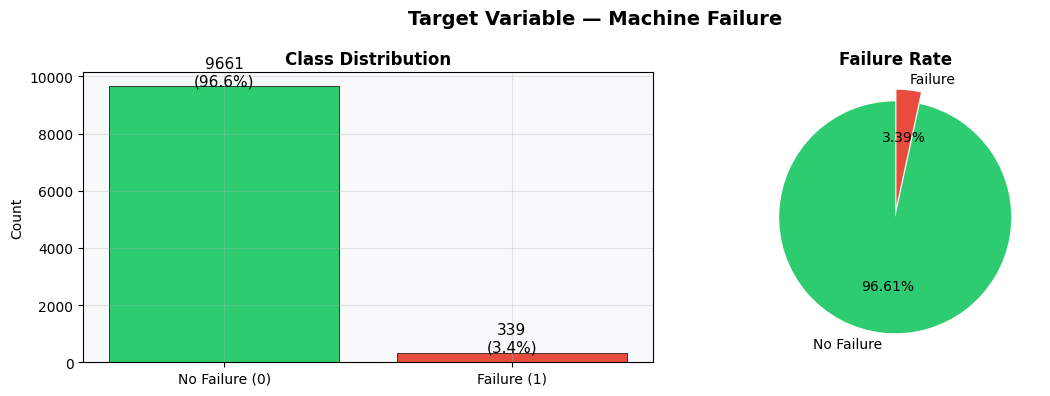

Imbalance ratio : 28.5:1  (No Failure : Failure)
→ Dataset is heavily imbalanced. We will use SMOTE to fix this.


In [4]:
# ── 1. Target class distribution ─────────────────────────────
# This tells us how imbalanced the data is.
# If the dataset were balanced we would expect 50% failures.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Machine failure'].value_counts()

axes[0].bar(['No Failure (0)', 'Failure (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

axes[1].pie(counts.values, labels=['No Failure', 'Failure'],
            autopct='%1.2f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Failure Rate', fontweight='bold')

plt.suptitle('Target Variable — Machine Failure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Imbalance ratio : {counts[0]/counts[1]:.1f}:1  (No Failure : Failure)")
print("→ Dataset is heavily imbalanced. We will use SMOTE to fix this.")

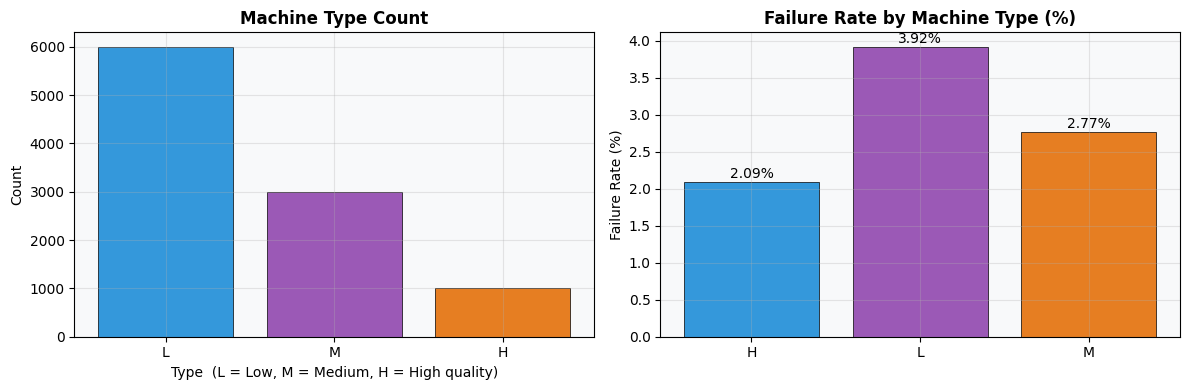

In [5]:
# ── 2. Machine type distribution and failure rate by type ─────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

type_counts = df['Type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['#3498db', '#9b59b6', '#e67e22'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Machine Type Count', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Type  (L = Low, M = Medium, H = High quality)')

fail_rate = df.groupby('Type')['Machine failure'].mean() * 100
axes[1].bar(fail_rate.index, fail_rate.values,
            color=['#3498db', '#9b59b6', '#e67e22'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Failure Rate by Machine Type (%)', fontweight='bold')
axes[1].set_ylabel('Failure Rate (%)')
for i, (idx, val) in enumerate(fail_rate.items()):
    axes[1].text(i, val + 0.05, f'{val:.2f}%', ha='center')

plt.tight_layout()
plt.show()

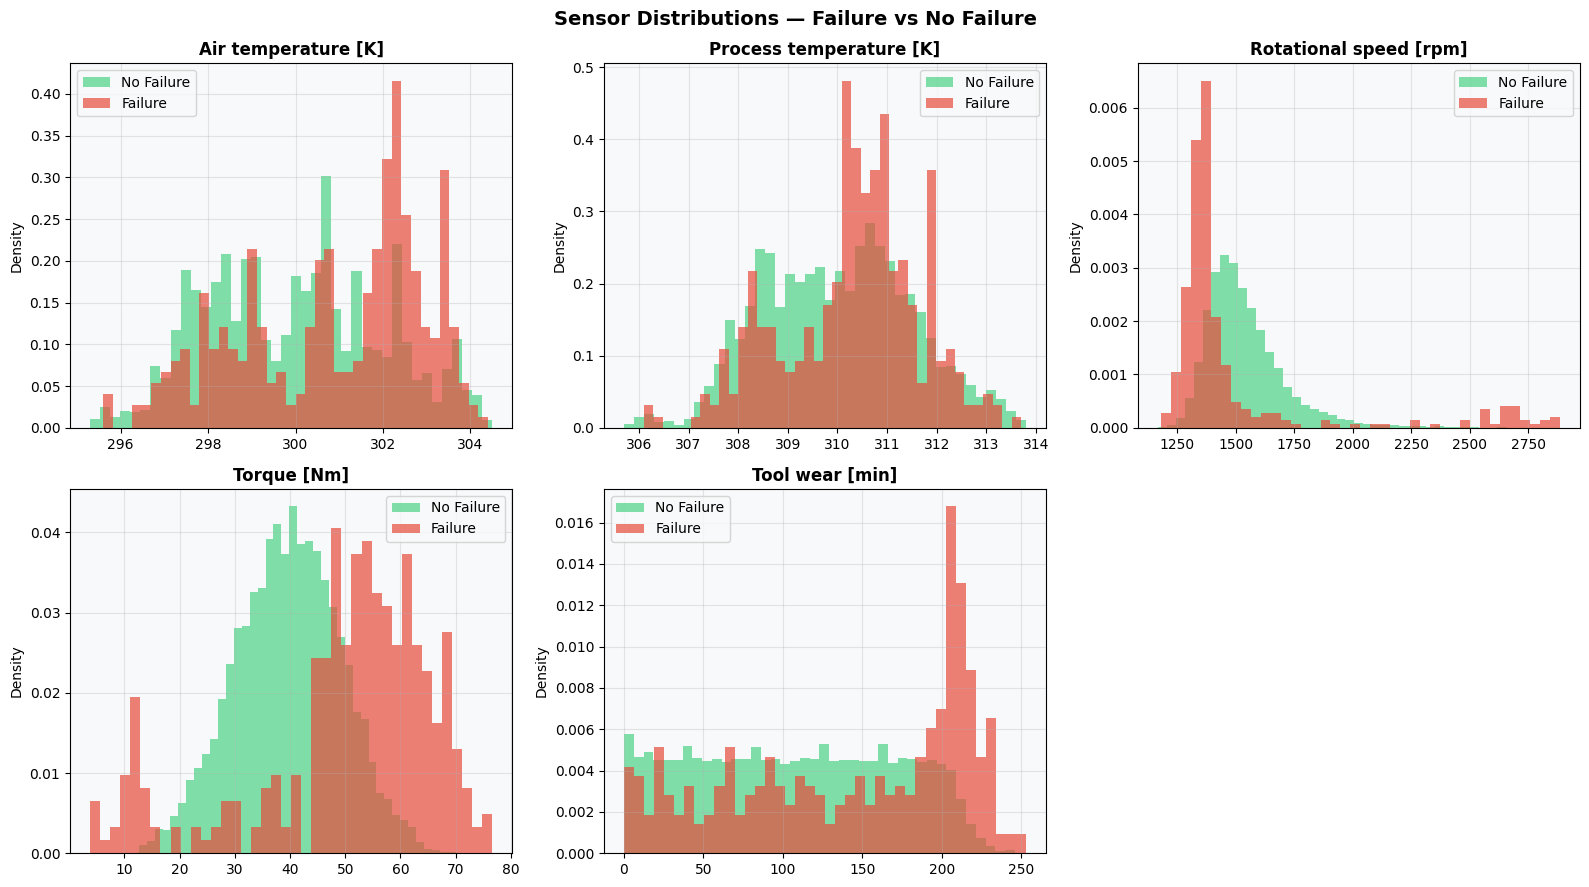

In [6]:
# ── 3. Sensor feature distributions: failure vs no failure ────
# Overlapping histograms — wide separation means the feature is useful for prediction.
sensor_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(sensor_features):
    axes[i].hist(df[df['Machine failure'] == 0][feat], bins=40, alpha=0.6,
                 color='#2ecc71', label='No Failure', density=True)
    axes[i].hist(df[df['Machine failure'] == 1][feat], bins=40, alpha=0.7,
                 color='#e74c3c', label='Failure', density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend()

axes[5].axis('off')
plt.suptitle('Sensor Distributions — Failure vs No Failure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

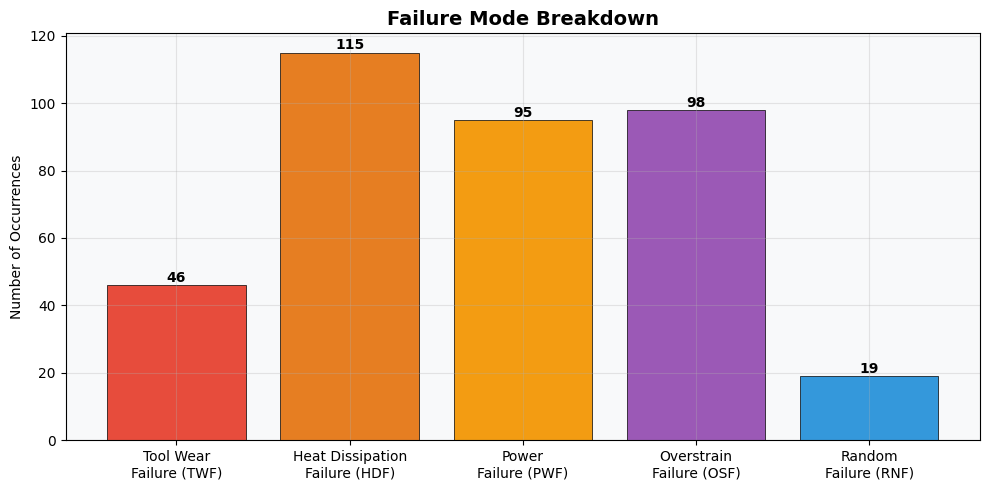

In [7]:
# ── 4. Failure mode breakdown ─────────────────────────────────
# The dataset labels each failure with a subtype. This shows which is most common.
failure_types  = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_labels = [
    'Tool Wear\nFailure (TWF)',
    'Heat Dissipation\nFailure (HDF)',
    'Power\nFailure (PWF)',
    'Overstrain\nFailure (OSF)',
    'Random\nFailure (RNF)'
]
failure_counts = df[failure_types].sum().values

plt.figure(figsize=(10, 5))
bars = plt.bar(failure_labels, failure_counts,
               color=['#e74c3c','#e67e22','#f39c12','#9b59b6','#3498db'],
               edgecolor='black', linewidth=0.5)
plt.title('Failure Mode Breakdown', fontsize=14, fontweight='bold')
plt.ylabel('Number of Occurrences')
for bar, val in zip(bars, failure_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

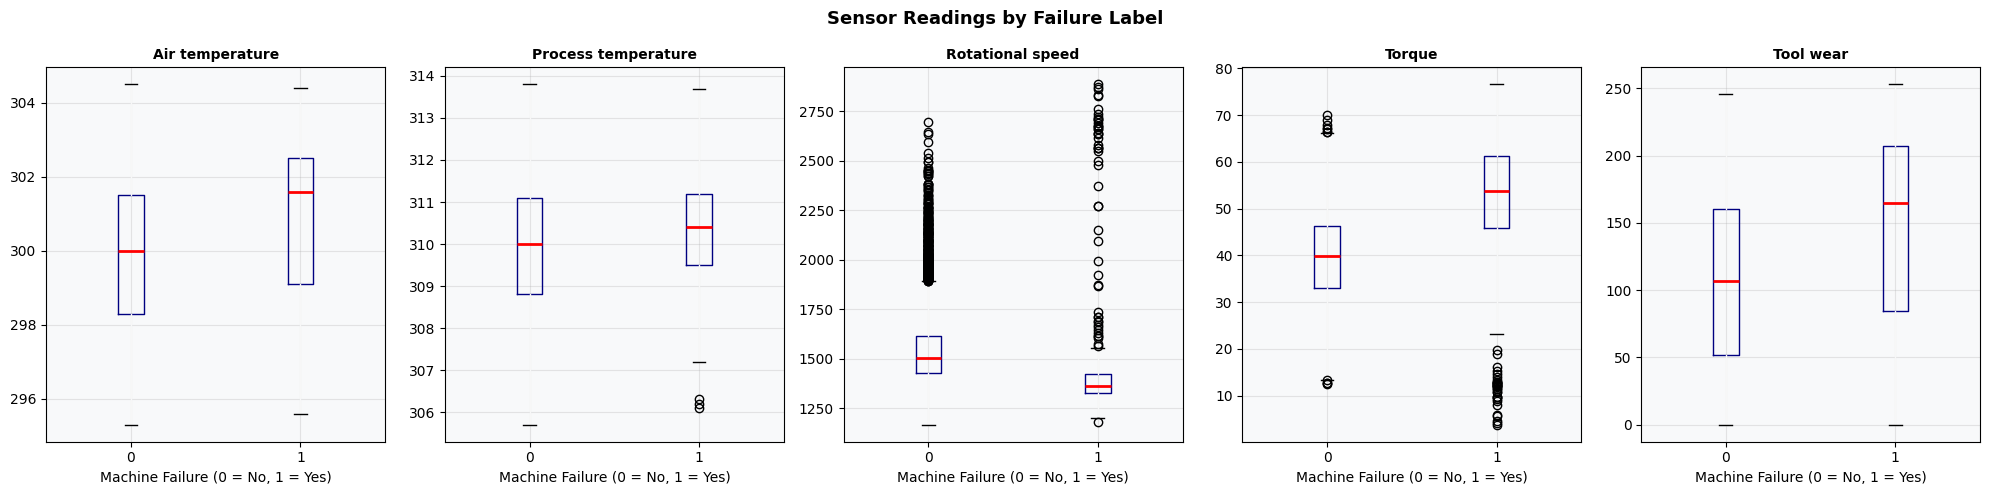

In [8]:
# ── 5. Boxplots: sensor readings by failure label ─────────────
# Separated boxes = the feature carries signal for prediction.
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, feat in enumerate(sensor_features):
    df.boxplot(column=feat, by='Machine failure', ax=axes[i],
               boxprops=dict(color='navy'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat.split('[')[0].strip(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Machine Failure (0 = No, 1 = Yes)')

plt.suptitle('Sensor Readings by Failure Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

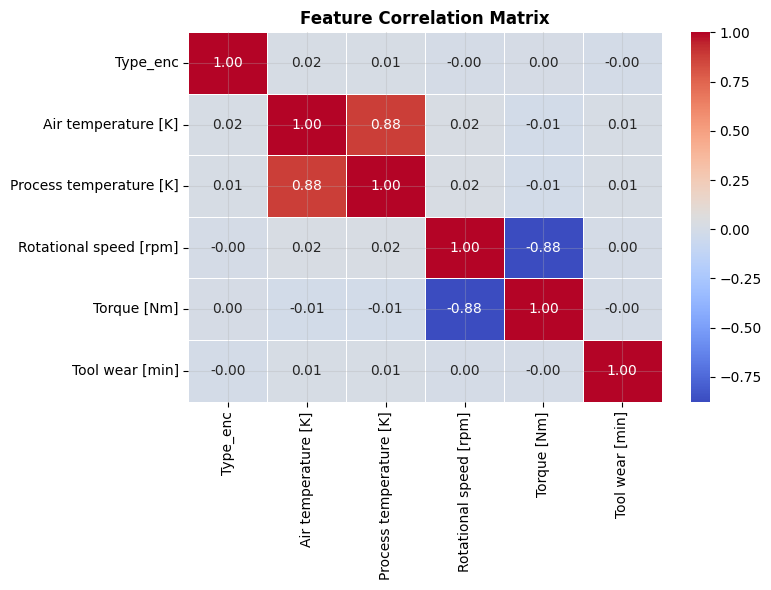

→ Air temperature and Process temperature are highly correlated (>0.87)
  This means they carry very similar information — one can be dropped.


In [9]:
# ── 6. Correlation heatmap ────────────────────────────────────
# Values near +1 or -1 = strong relationship between two features.
# High correlation between INPUT features means redundant information — a candidate for removal.
df_processed = df.copy()
le = LabelEncoder()
df_processed['Type_enc'] = le.fit_transform(df_processed['Type'])

feature_cols_all = [
    'Type_enc',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

corr_matrix = df_processed[feature_cols_all].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, linecolor='white')
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print("→ Air temperature and Process temperature are highly correlated (>0.87)")
print("  This means they carry very similar information — one can be dropped.")

---
## Phase 4 — Feature Analysis & Reduction

We use two methods to decide which features to keep:

1. **Random Forest Feature Importance** — which features does the model rely on most?
2. **PCA (Principal Component Analysis)** — how many components are needed to explain 95% of variance?

Based on the correlation heatmap (Phase 3) and feature importance below, we remove:
- `Type_enc` — low importance
- `Process temperature [K]` — highly correlated with Air temperature (redundant)

This leaves us with **4 clean features** that carry the most useful information.


Feature Importance Ranking:


,Feature,Importance
4,Torque [Nm],0.322782
3,Rotational speed [rpm],0.222288
5,Tool wear [min],0.162396
1,Air temperature [K],0.140107
2,Process temperature [K],0.128520
0,Type_enc,0.023907


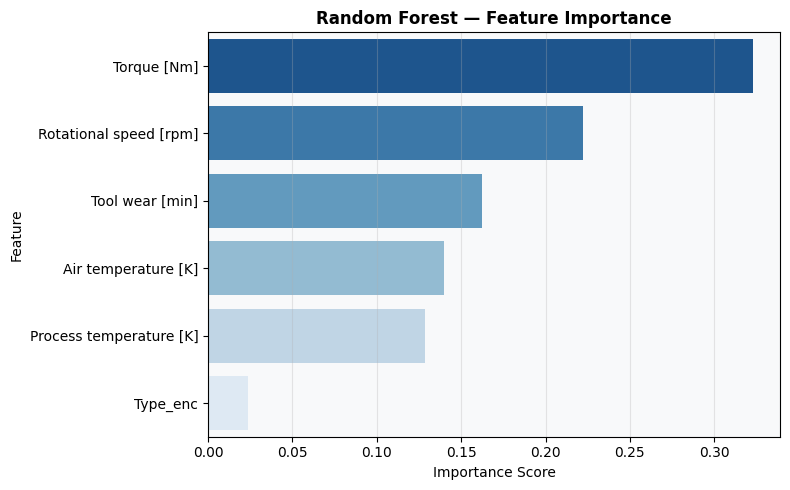

In [10]:
# ── Feature importance using Random Forest ────────────────────
# We train a quick Random Forest on all 6 features just to rank them.
# The importance score tells us how much each feature contributed to predictions.

X_all = df_processed[feature_cols_all]
y_all = df_processed['Machine failure']

rf_imp = RandomForestClassifier(n_estimators=300, random_state=SEED)
rf_imp.fit(X_all, y_all)

importance_df = pd.DataFrame({
    'Feature'   : feature_cols_all,
    'Importance': rf_imp.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance Ranking:")
display(importance_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Random Forest — Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

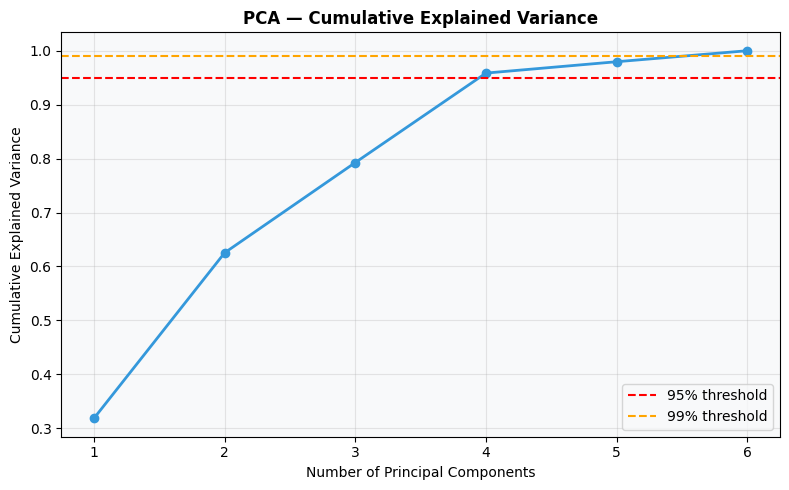

Components needed for 95% variance : 4
Explained variance per component   : [0.3185 0.3069 0.1673 0.1659 0.0211 0.0204]

→ 4 components out of 6 explain 95% of variance.
→ Combined with feature importance, we reduce to 4 features.


In [11]:
# ── PCA: how many components explain 95% of variance? ─────────
# We scale first (PCA requires it), then check how many components
# are needed to capture 95% of the information in the data.

scaler_pca = StandardScaler()
X_all_sc   = scaler_pca.fit_transform(X_all)

pca_full = PCA(random_state=SEED)
pca_full.fit(X_all_sc)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, 'o-', linewidth=2, color='#3498db')
plt.axhline(0.95, color='red',  linestyle='--', label='95% threshold')
plt.axhline(0.99, color='orange', linestyle='--', label='99% threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

n_95 = int(np.argmax(cumulative_var >= 0.95)) + 1
print(f"Components needed for 95% variance : {n_95}")
print(f"Explained variance per component   : {pca_full.explained_variance_ratio_.round(4)}")
print(f"\n→ {n_95} components out of 6 explain 95% of variance.")
print("→ Combined with feature importance, we reduce to 4 features.")

In [12]:
# ── Final reduced feature set ─────────────────────────────────
# Decision: remove Type_enc (lowest importance) and
# Process temperature (highly correlated with Air temperature).
# These 4 features carry the most independent, useful information.

FEATURE_COLS = [
    'Air temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

X = df_processed[FEATURE_COLS]
y = df_processed['Machine failure']

print("Selected features:")
for f in FEATURE_COLS:
    print(f"  - {f}")
print(f"\nFeature matrix shape : {X.shape}")
print(f"Target distribution  :\n{y.value_counts()}")

Selected features:
  - Air temperature [K]
  - Rotational speed [rpm]
  - Torque [Nm]
  - Tool wear [min]

Feature matrix shape : (10000, 4)
Target distribution  :
Machine failure
0    9661
1     339
Name: count, dtype: int64


---
## Phase 5 — Data Preprocessing

Three steps before training any model:

### Step 1 — SMOTE (handle class imbalance)
The dataset has ~97% no-failure and ~3% failure samples.
Training on raw imbalanced data causes the model to simply predict "no failure" always and still get 97% accuracy — which is useless.
SMOTE creates **synthetic failure samples** by interpolating between existing ones until both classes are equal.

### Step 2 — Train / Validation / Test Split (70 / 15 / 15)
- **Train set** — the model learns from this
- **Validation set** — used to tune and compare models during development
- **Test set** — locked away until the very end; gives an honest performance estimate

### Step 3 — Feature Scaling
StandardScaler transforms every feature to have mean = 0 and std = 1.
**Important:** the scaler is fitted on training data only, then applied to validation and test.
Fitting on test data would be "data leakage" — the model would be cheating.


In [13]:
# ── Step 1: SMOTE ─────────────────────────────────────────────
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Before SMOTE : {dict(y.value_counts())}")
print(f"After  SMOTE : {dict(pd.Series(y_resampled).value_counts())}")
print(f"Total samples: {len(X_resampled):,}")

Before SMOTE : {0: np.int64(9661), 1: np.int64(339)}
After  SMOTE : {0: np.int64(9661), 1: np.int64(9661)}
Total samples: 19,322


In [14]:
# ── Step 2: Train / Validation / Test split ───────────────────
# stratify= ensures both splits keep the same class ratio

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.15, random_state=SEED, stratify=y_resampled
)

# 0.176 of the remaining 85% gives roughly 15% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.176, random_state=SEED, stratify=y_train_full
)

print(f"Train      : {len(X_train):,} samples  (~70%)")
print(f"Validation : {len(X_val):,} samples  (~15%)")
print(f"Test       : {len(X_test):,} samples  (~15%)")
print("\n→ Test set is now locked. It will only be used in Phase 7.")

Train      : 13,532 samples  (~70%)
Validation : 2,891 samples  (~15%)
Test       : 2,899 samples  (~15%)

→ Test set is now locked. It will only be used in Phase 7.


In [15]:
# ── Step 3: Feature scaling ───────────────────────────────────
# fit_transform on train: compute mean/std FROM training data, then scale it
# transform only on val/test: apply the SAME mean/std — no peeking at test data

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform
X_val_sc   = scaler.transform(X_val)         # transform only
X_test_sc  = scaler.transform(X_test)        # transform only

print("Scaling complete.")
print(f"Train mean (should be ≈ 0) : {X_train_sc.mean():.6f}")
print(f"Train std  (should be ≈ 1) : {X_train_sc.std():.6f}")

Scaling complete.
Train mean (should be ≈ 0) : -0.000000
Train std  (should be ≈ 1) : 1.000000


---
## Phase 6 — Model Training & Learning Curves

We train 5 classifiers on the 4 reduced features.

### What is a Learning Curve?
A learning curve plots **Train F1 vs Validation F1** as the model sees increasing amounts of training data.

| What you see | What it means |
|---|---|
| Train = 1.00 flat, big gap to val | **Overfitting** — model memorised training data |
| Both lines low and flat | **Underfitting** — model is too simple |
| Lines converge and rise together | **Healthy** — model generalises well |

The shaded band around each line = ± 1 standard deviation across 5 cross-validation folds.
A narrow band means the model is stable; a wide band means it behaves inconsistently.

### Overfitting controls applied
Decision Tree and Random Forest grow until every training sample is perfectly classified by default (Train F1 = 1.00).
We add `max_depth`, `min_samples_leaf`, and `min_samples_split` to prevent this.


In [16]:
# ── Define all models ─────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=SEED
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth         = 8,
        min_samples_leaf  = 5,
        min_samples_split = 10,
        random_state      = SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators      = 100,
        max_depth         = 10,
        min_samples_leaf  = 5,
        min_samples_split = 10,
        random_state      = SEED
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators  = 100,
        max_depth     = 4,
        learning_rate = 0.1,
        random_state  = SEED
    ),
    'SVM (RBF)': SVC(
        kernel      = 'rbf',
        C           = 1.0,
        probability = True,
        random_state= SEED
    ),
    'KNN': KNeighborsClassifier(   # ← add this
        n_neighbors = 2
    ),
}

print("Models defined:")
for name in models:
    print(f"  - {name}")

Models defined:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - SVM (RBF)
  - KNN


In [17]:
# ── Train all models ──────────────────────────────────────────
trained_models = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    trained_models[name] = model
    print(f"  ✓ {name} trained")

print("\n✅ All models trained on 4 reduced features.")

  ✓ Logistic Regression trained
  ✓ Decision Tree trained
  ✓ Random Forest trained
  ✓ Gradient Boosting trained
  ✓ SVM (RBF) trained
  ✓ KNN trained

✅ All models trained on 4 reduced features.


── Logistic Regression ──


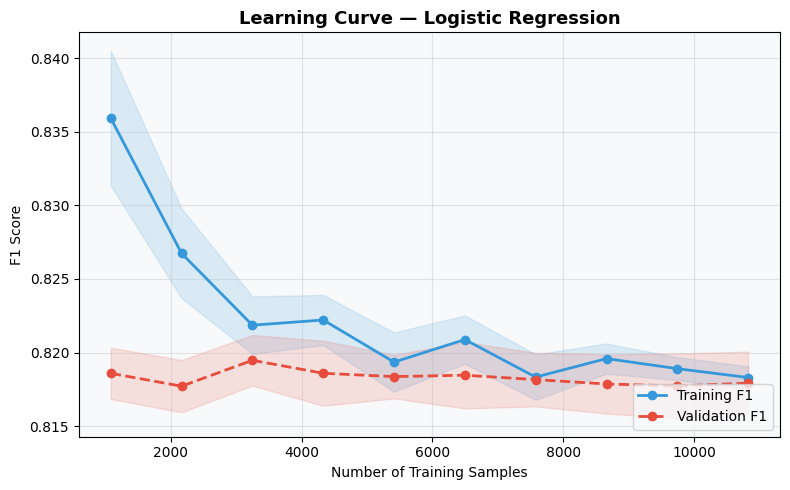

  Final Train F1 : 0.8183
  Final Val   F1 : 0.8179
  Gap            : 0.0004  ✅ looks healthy

── Decision Tree ──


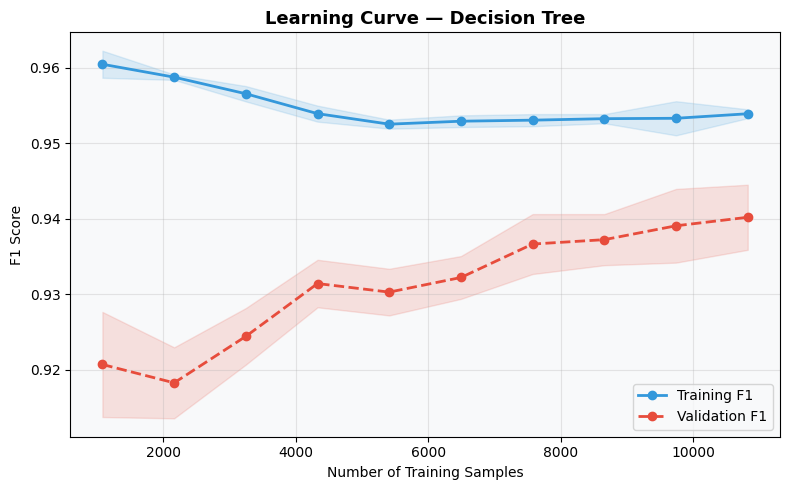

  Final Train F1 : 0.9539
  Final Val   F1 : 0.9402
  Gap            : 0.0137  ✅ looks healthy

── Random Forest ──


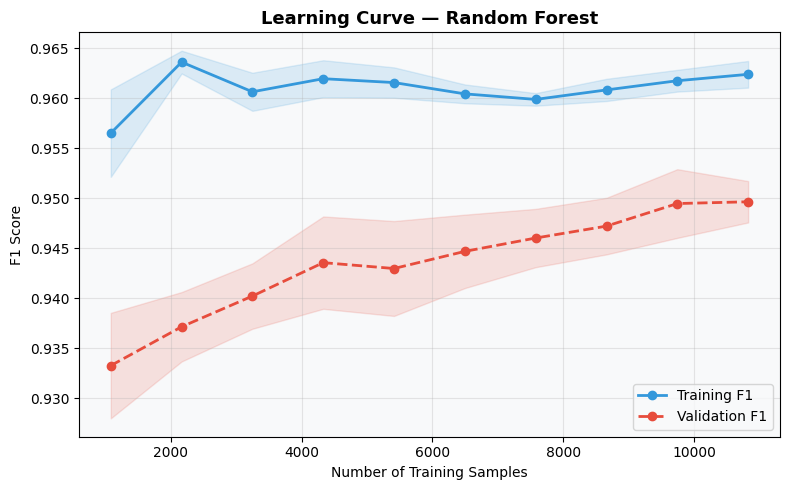

  Final Train F1 : 0.9624
  Final Val   F1 : 0.9496
  Gap            : 0.0127  ✅ looks healthy

── Gradient Boosting ──


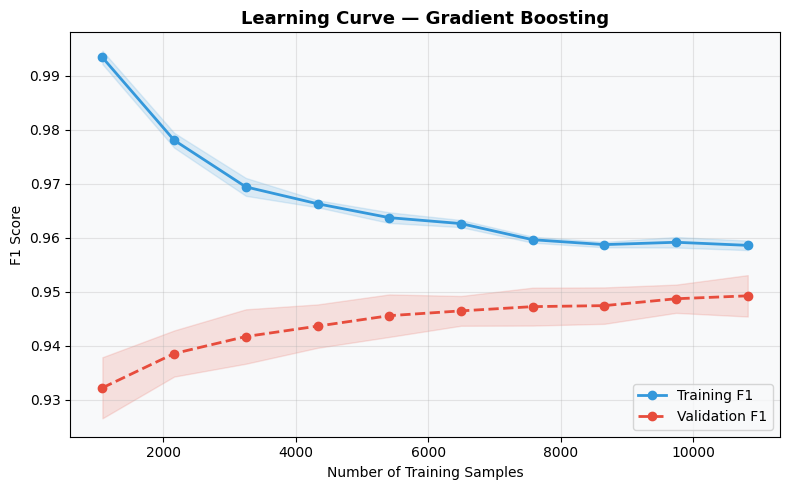

  Final Train F1 : 0.9586
  Final Val   F1 : 0.9492
  Gap            : 0.0094  ✅ looks healthy

── SVM (RBF) ──


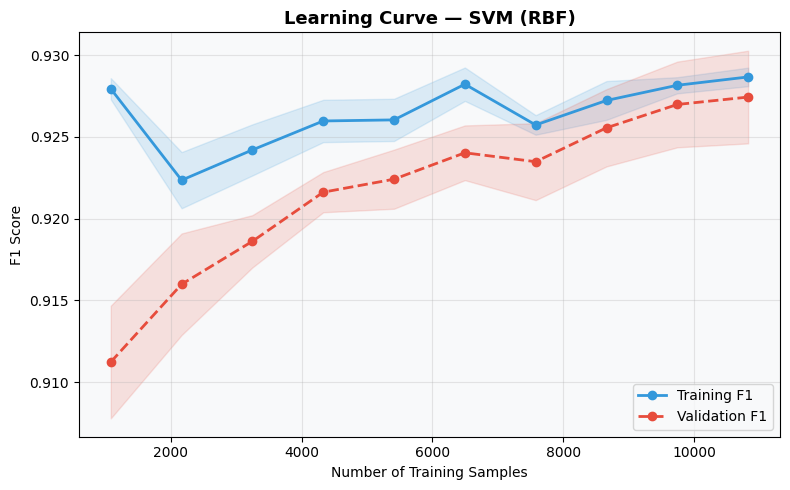

  Final Train F1 : 0.9287
  Final Val   F1 : 0.9274
  Gap            : 0.0012  ✅ looks healthy

── KNN ──


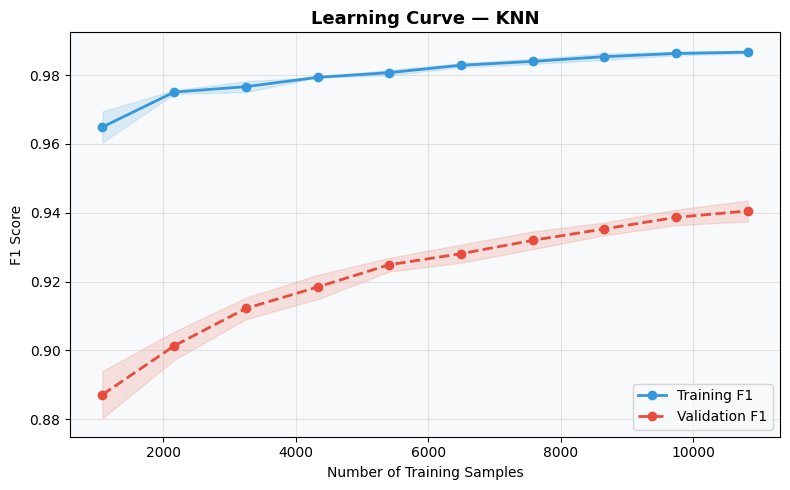

  Final Train F1 : 0.9867
  Final Val   F1 : 0.9405
  Gap            : 0.0462  ✅ looks healthy



In [18]:
# ── Learning curve function ───────────────────────────────────
def plot_learning_curve(model, model_name, X_tr, y_tr, cv=5):
    """
    Plots train F1 vs validation F1 as training size increases.
    Blue line  = training score (how well the model fits training data)
    Red line   = validation score (how well it generalises to new data)
    Shaded band = ± 1 std across cv folds (width shows stability)
    """
    train_sizes, train_scores, val_scores = learning_curve(
        estimator   = model,
        X           = X_tr,
        y           = y_tr,
        cv          = cv,
        scoring     = 'f1',
        train_sizes = np.linspace(0.1, 1.0, 10),
        n_jobs      = -1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(8, 5))

    # Training score
    plt.plot(train_sizes, train_mean, 'o-', color='#3498db', linewidth=2, label='Training F1')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.15, color='#3498db')

    # Validation score
    plt.plot(train_sizes, val_mean, 'o--', color='#e74c3c', linewidth=2, label='Validation F1')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                     alpha=0.15, color='#e74c3c')

    plt.title(f'Learning Curve — {model_name}', fontweight='bold', fontsize=13)
    plt.xlabel('Number of Training Samples')
    plt.ylabel('F1 Score')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    gap = train_mean[-1] - val_mean[-1]
    print(f"  Final Train F1 : {train_mean[-1]:.4f}")
    print(f"  Final Val   F1 : {val_mean[-1]:.4f}")
    print(f"  Gap            : {gap:.4f}  {'⚠️  possible overfitting' if gap > 0.05 else '✅ looks healthy'}\n")


# ── Plot learning curves for all models ───────────────────────
for name, model in trained_models.items():
    print(f"── {name} ──")
    plot_learning_curve(model, name, X_train_sc, y_train)

---
## Phase 7 — Final Evaluation on Unseen Test Data

This is the most important phase. Up to this point, every model has only seen the
**training** and **validation** sets. The **test set** was locked away since Phase 5.

Evaluating on the test set gives an honest, unbiased estimate of real-world performance.

We report:

| Metric | Why it matters here |
|--------|-------------------|
| **Accuracy** | Overall correct predictions (can mislead on imbalanced data) |
| **Precision** | Of predicted failures, how many were real? |
| **Recall** | Of all real failures, how many did we catch? ← most important in maintenance |
| **F1-Score** | Balance of precision and recall |
| **AUC-ROC** | Ability to distinguish failure from non-failure at any threshold |
| **MCC** | Most reliable single metric for imbalanced binary classification |

> **Recall is the most critical metric here.** A missed failure (False Negative)
> means a machine breaks down unexpectedly — far more costly than a false alarm.


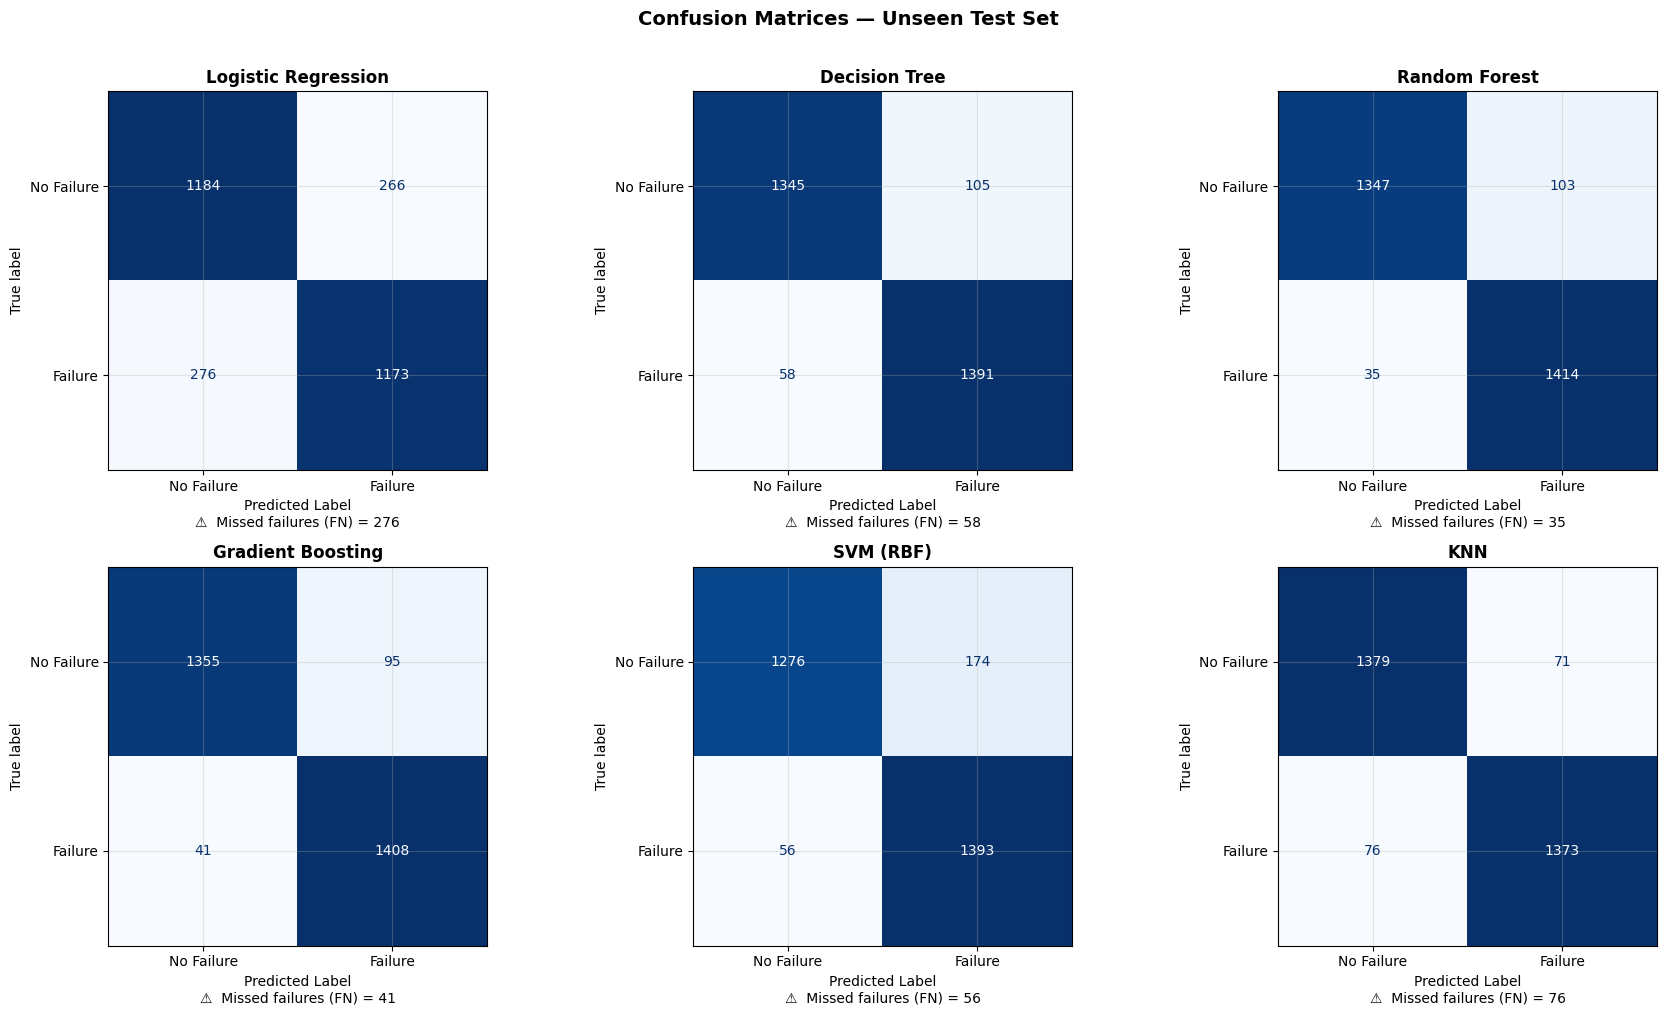

In [19]:
# ── Confusion Matrices — all models on test set ───────────────
# Each matrix shows:
#   Top-left  (TN) = correctly predicted no failure
#   Top-right (FP) = false alarm — predicted failure, machine was fine
#   Bottom-left (FN) = MISSED a real failure ← most dangerous
#   Bottom-right (TP) = correctly caught a failure

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_sc)
    cm     = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix = cm,
        display_labels   = ['No Failure', 'Failure']
    )
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontweight='bold', fontsize=12)

    fn = cm[1][0]  # bottom-left cell = missed failures
    axes[i].set_xlabel(
        f'Predicted Label\n⚠️  Missed failures (FN) = {fn}',
        fontsize=10
    )

#axes[5].axis('off')  # hide unused 6th subplot

plt.suptitle('Confusion Matrices — Unseen Test Set',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

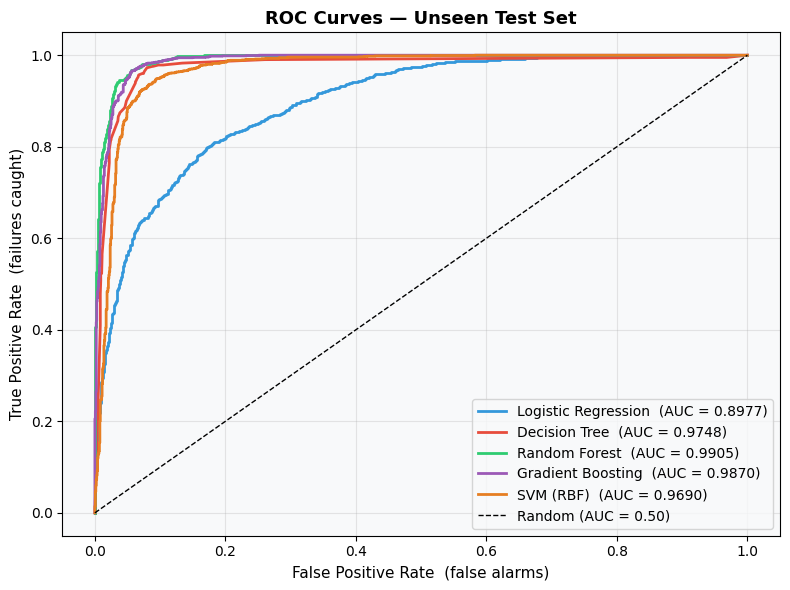

In [20]:
# ── ROC Curves — all models ───────────────────────────────────
# The ROC curve plots True Positive Rate vs False Positive Rate at every decision threshold.
# A curve hugging the top-left corner = excellent model.
# AUC = 1.0 is perfect; AUC = 0.5 = random guessing.

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#e67e22']

plt.figure(figsize=(8, 6))

for (name, model), color in zip(trained_models.items(), colors):
    y_prob      = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val     = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, color=color,
             label=f'{name}  (AUC = {auc_val:.4f})')

# Diagonal = random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate  (false alarms)',  fontsize=11)
plt.ylabel('True Positive Rate  (failures caught)', fontsize=11)
plt.title('ROC Curves — Unseen Test Set', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

In [21]:
# ── Final Unified Results Table ───────────────────────────────
# All models evaluated on the SAME test set — fair, apples-to-apples comparison.
# Green highlight = best value in each column.

final_results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    final_results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test,  y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test,    y_pred), 4),
        'F1-Score' : round(f1_score(y_test,        y_pred), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test,   y_prob), 4),
        'MCC'      : round(matthews_corrcoef(y_test,y_pred), 4),
    })

results_df = (
    pd.DataFrame(final_results)
    .set_index('Model')
    .sort_values('F1-Score', ascending=False)
)

print("=" * 68)
print("  FINAL MODEL COMPARISON — Unseen Test Set")
print("=" * 68)

display(
    results_df.style.highlight_max(
        subset=['Accuracy','Precision','Recall','F1-Score','AUC-ROC','MCC'],
        color='#d4edda'
    )
)

  FINAL MODEL COMPARISON — Unseen Test Set


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,MCC
Model,,,,,,
Gradient Boosting,0.953100,0.936800,0.971700,0.953900,0.987000,0.906800
Random Forest,0.952400,0.932100,0.975800,0.953500,0.990500,0.905800
KNN,0.949300,0.950800,0.947600,0.949200,0.969200,0.898600
Decision Tree,0.943800,0.929800,0.960000,0.944700,0.974800,0.888000
SVM (RBF),0.920700,0.889000,0.961400,0.923700,0.969000,0.844100
Logistic Regression,0.813000,0.815100,0.809500,0.812300,0.897700,0.626100


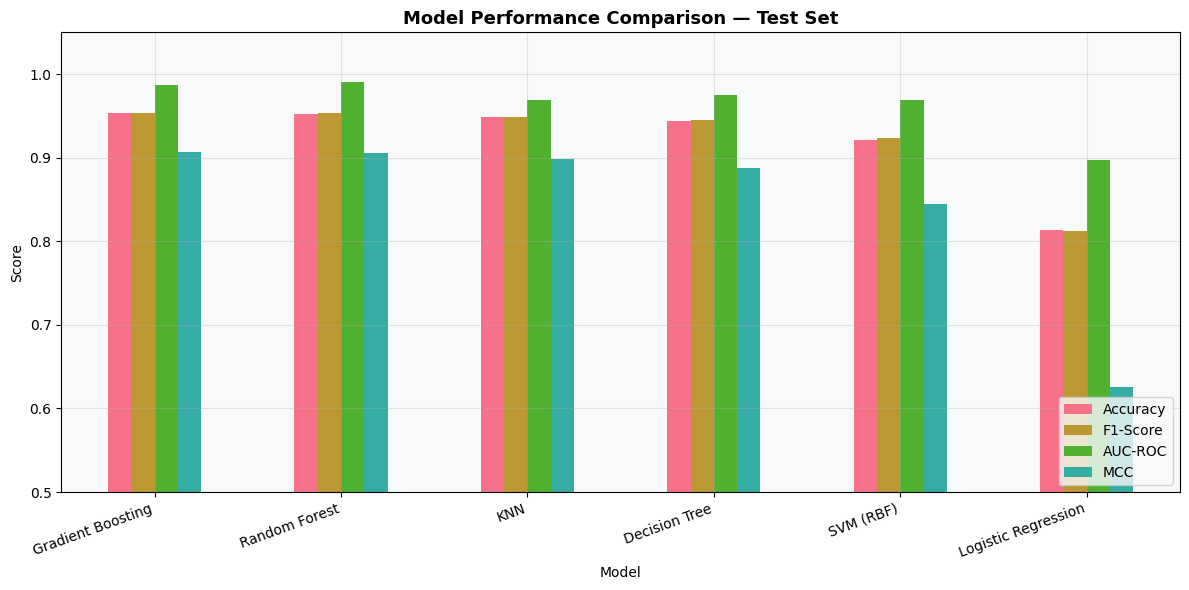

In [22]:
# ── Performance bar chart ─────────────────────────────────────
results_df[['Accuracy', 'F1-Score', 'AUC-ROC', 'MCC']].plot(
    kind='bar', figsize=(12, 6)
)
plt.title('Model Performance Comparison — Test Set', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.5, 1.05)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [23]:
# ── Best model summary ────────────────────────────────────────
best = results_df['F1-Score'].idxmax()

print("=" * 50)
print("  BEST MODEL")
print("=" * 50)
print(f"  Model     : {best}")
print(f"  Accuracy  : {results_df.loc[best, 'Accuracy']:.4f}")
print(f"  Precision : {results_df.loc[best, 'Precision']:.4f}")
print(f"  Recall    : {results_df.loc[best, 'Recall']:.4f}  ← % of real failures caught")
print(f"  F1-Score  : {results_df.loc[best, 'F1-Score']:.4f}")
print(f"  AUC-ROC   : {results_df.loc[best, 'AUC-ROC']:.4f}")
print(f"  MCC       : {results_df.loc[best, 'MCC']:.4f}")
print("=" * 50)

print(f"\n=== Detailed Classification Report — {best} ===")
best_model = trained_models[best]
print(classification_report(y_test, best_model.predict(X_test_sc),
                             target_names=['No Failure', 'Failure']))

  BEST MODEL
  Model     : Gradient Boosting
  Accuracy  : 0.9531
  Precision : 0.9368
  Recall    : 0.9717  ← % of real failures caught
  F1-Score  : 0.9539
  AUC-ROC   : 0.9870
  MCC       : 0.9068

=== Detailed Classification Report — Gradient Boosting ===
              precision    recall  f1-score   support

  No Failure       0.97      0.93      0.95      1450
     Failure       0.94      0.97      0.95      1449

    accuracy                           0.95      2899
   macro avg       0.95      0.95      0.95      2899
weighted avg       0.95      0.95      0.95      2899



---
## Summary

| Decision | Rationale |
|----------|-----------|
| **4 features kept** | Removed `Type_enc` (lowest importance) and `Process temperature` (redundant — correlated >0.87 with Air temperature) |
| **SMOTE applied** | Raw 3% failure rate would cause models to always predict "no failure" |
| **3-way split** | Test set locked until final evaluation — prevents optimistic bias |
| **max_depth limits added** | Prevents Decision Tree and Random Forest from memorising training data (Train F1 = 1.00) |
| **Learning curves** | Show train vs validation F1 per training size — real overfitting diagnostic |
| **MCC included** | Most reliable metric for imbalanced binary classification |
| **Confusion matrix** | Makes False Negatives (missed failures) visible — the most dangerous error in maintenance |
